In [1]:
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

import common
from model.features import (
    add_distance_features,
    add_time_features,
    add_trip_type_features,
    build_abnormal_dates,
    haversine_array,
    is_high_speed_trip,
    is_high_traffic_trip,
    is_rare_point,
)
from model.preprocessing import (
    add_model_features,
    transform_target,
    undo_step3_process_features,
)

In [2]:
CSV_PATH = f"{common.CONFIG['paths']['raw_data']}/{common.CONFIG['dataset']['csv_file']}"
RANDOM_STATE = int(common.CONFIG["ml"]["random_state"])

In [3]:
def show_circles_on_map(data, latitude_column, longitude_column, color):
    """Draw a map with circles."""
    location = (data[latitude_column].mean(), data[longitude_column].mean())
    m = folium.Map(location=location)

    for _, row in data.iterrows():
        folium.Circle(
            radius=100,
            location=(row[latitude_column], row[longitude_column]),
            color=color,
            fill_color=color,
            fill=True,
        ).add_to(m)

    return m

In [4]:
data = pd.read_csv(CSV_PATH)
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"])

In [5]:
X = data.drop(columns=["trip_duration"])
y = transform_target(data["trip_duration"])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

In [7]:
abnormal_dates = build_abnormal_dates(X)
X = add_time_features(X, abnormal_dates)
X_train = add_time_features(X_train, abnormal_dates)
X_test = add_time_features(X_test, abnormal_dates)

In [8]:
# pickup points on a map
show_circles_on_map(data.sample(1000), "pickup_latitude", "pickup_longitude", "blue")


In [9]:
# distance and speed
distance_haversine = haversine_array(
    X["pickup_latitude"],
    X["pickup_longitude"],
    X["dropoff_latitude"],
    X["dropoff_longitude"],
)

In [10]:
log_distance_haversine = np.log1p(distance_haversine)

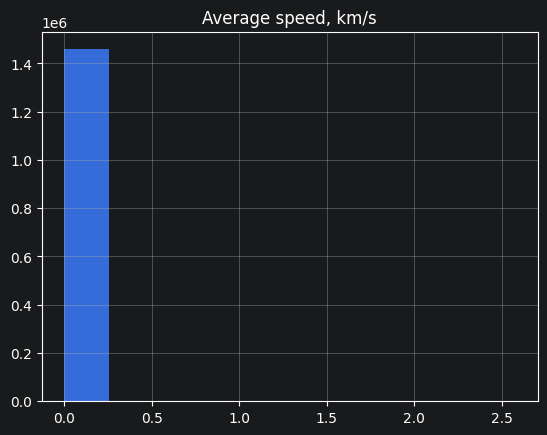

In [11]:
avg_speed = distance_haversine / np.expm1(y)
avg_speed.hist()
plt.title("Average speed, km/s")
plt.show()

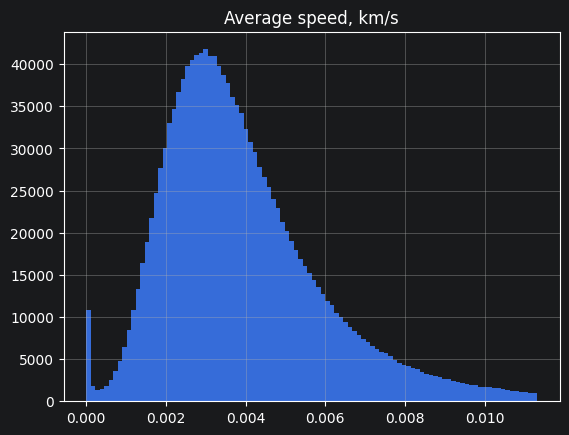

In [12]:
avg_speed[avg_speed < avg_speed.quantile(0.99)].hist(bins=100)
plt.title("Average speed, km/s")
plt.show()

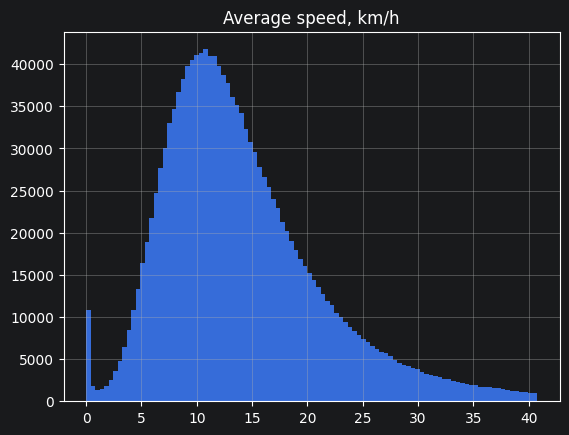

In [13]:
(avg_speed[avg_speed < avg_speed.quantile(0.99)] * 3600).hist(bins=100)
plt.title("Average speed, km/h")
plt.show()

In [14]:
data_plot = avg_speed.groupby([X["weekday"], X["hour"]]).median().rename("avg_speed").reset_index()
data_plot = data_plot.pivot(index="weekday", columns="hour", values="avg_speed")

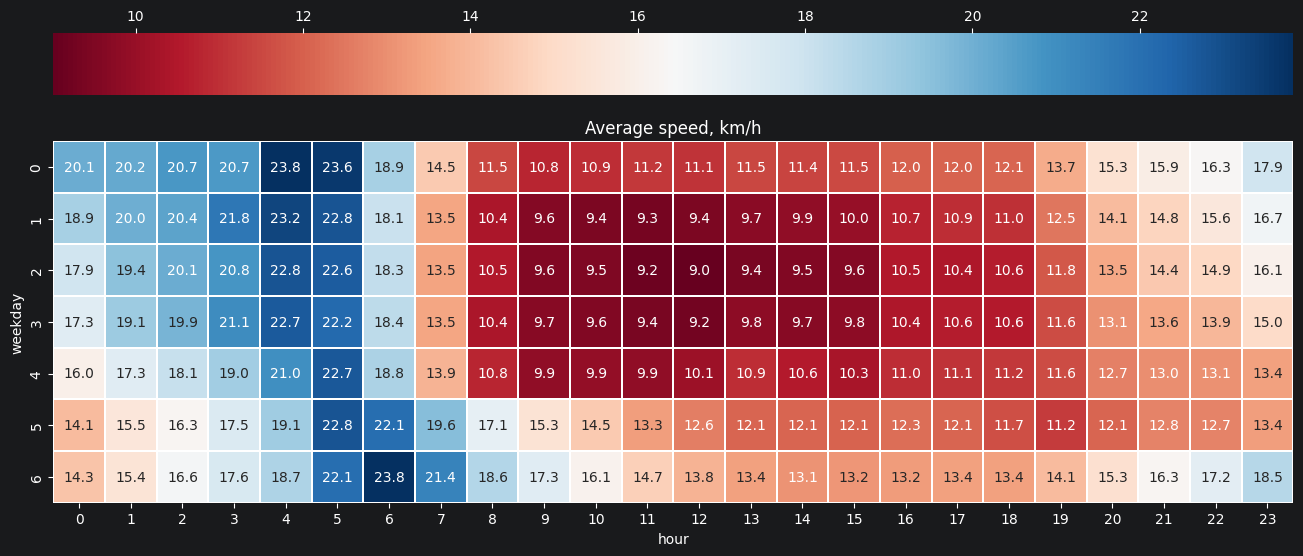

In [15]:
f, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    data_plot * 3600,
    annot=True,
    fmt=".1f",
    linewidths=0.1,
    square=True,
    cmap="RdBu",
    cbar_kws=dict(use_gridspec=False, location="top"),
)
plt.title("Average speed, km/h")
plt.show()

In [16]:
# traffic flags
high_traffic_trip_vec = is_high_traffic_trip(X).astype(int).rename("is_high_traffic_trip")
data_plot = pd.concat([X[["weekday", "hour"]], high_traffic_trip_vec], axis=1)
data_plot = data_plot.groupby(["weekday", "hour"])["is_high_traffic_trip"].mean().reset_index()
data_plot = data_plot.pivot(index="weekday", columns="hour", values="is_high_traffic_trip")

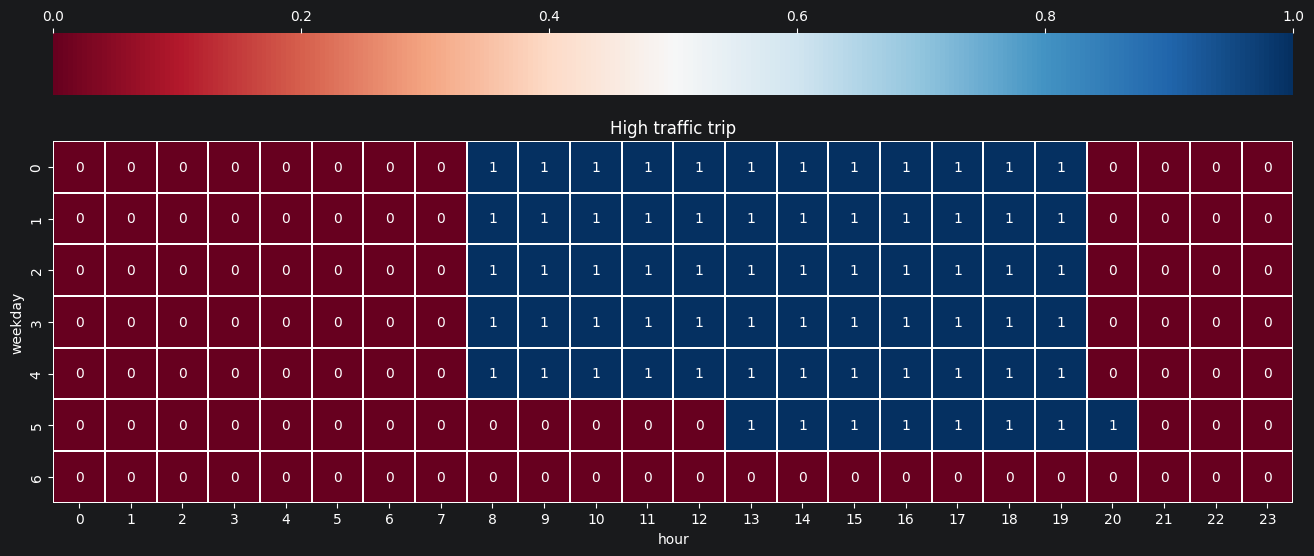

In [17]:
f, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(data_plot, annot=True, fmt=".0f", linewidths=0.1, square=True, cmap="RdBu", cbar_kws=dict(use_gridspec=False, location="top"))
plt.title("High traffic trip")
plt.show()

In [18]:
high_speed_trip_vec = is_high_speed_trip(X).astype(int).rename("is_high_speed_trip")
data_plot = pd.concat([X[["weekday", "hour"]], high_speed_trip_vec], axis=1)
data_plot = data_plot.groupby(["weekday", "hour"])["is_high_speed_trip"].mean().reset_index()
data_plot = data_plot.pivot(index="weekday", columns="hour", values="is_high_speed_trip")

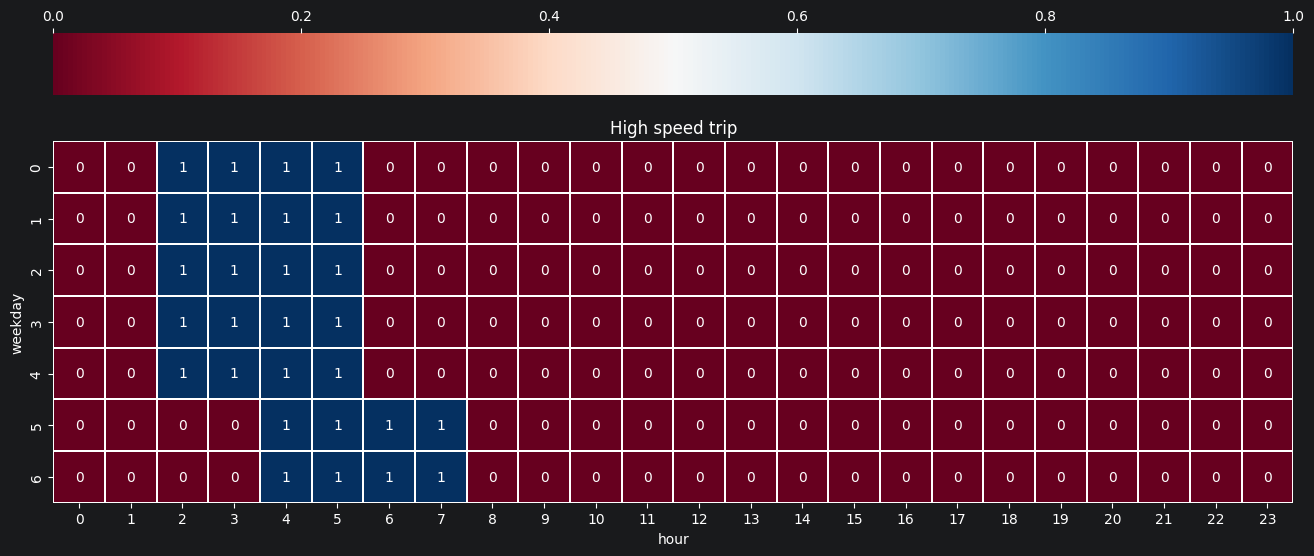

In [19]:
f, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(data_plot, annot=True, fmt=".0f", linewidths=0.1, square=True, cmap="RdBu", cbar_kws=dict(use_gridspec=False, location="top"))
plt.title("High speed trip")
plt.show()

In [20]:
# rare pickup points
latitude_column, longitude_column = "pickup_latitude", "pickup_longitude"
is_rare_point_vec = is_rare_point(X, latitude_column, longitude_column, 0.01, 0.995, 0, 0.95)
m = show_circles_on_map(data[~is_rare_point_vec].sample(1000), latitude_column, longitude_column, "blue")

rare_points = X[[latitude_column, longitude_column]][is_rare_point_vec]
for _, row in rare_points.sample(100).iterrows():
    folium.Circle(
        radius=100,
        location=(row[latitude_column], row[longitude_column]),
        color="red",
        fill_color="red",
        fill=True,
    ).add_to(m)
m

In [21]:
# rare dropoff points
latitude_column, longitude_column = "dropoff_latitude", "dropoff_longitude"
is_rare_point_vec = is_rare_point(X, latitude_column, longitude_column, 0.01, 0.995, 0.005, 0.95)
m = show_circles_on_map(data[~is_rare_point_vec].sample(1000), latitude_column, longitude_column, "blue")

rare_points = X[[latitude_column, longitude_column]][is_rare_point_vec]
for _, row in rare_points.sample(100).iterrows():
    folium.Circle(
        radius=100,
        location=(row[latitude_column], row[longitude_column]),
        color="red",
        fill_color="red",
        fill=True,
    ).add_to(m)
m

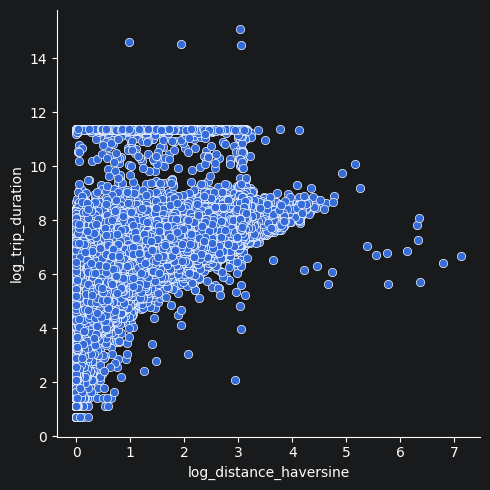

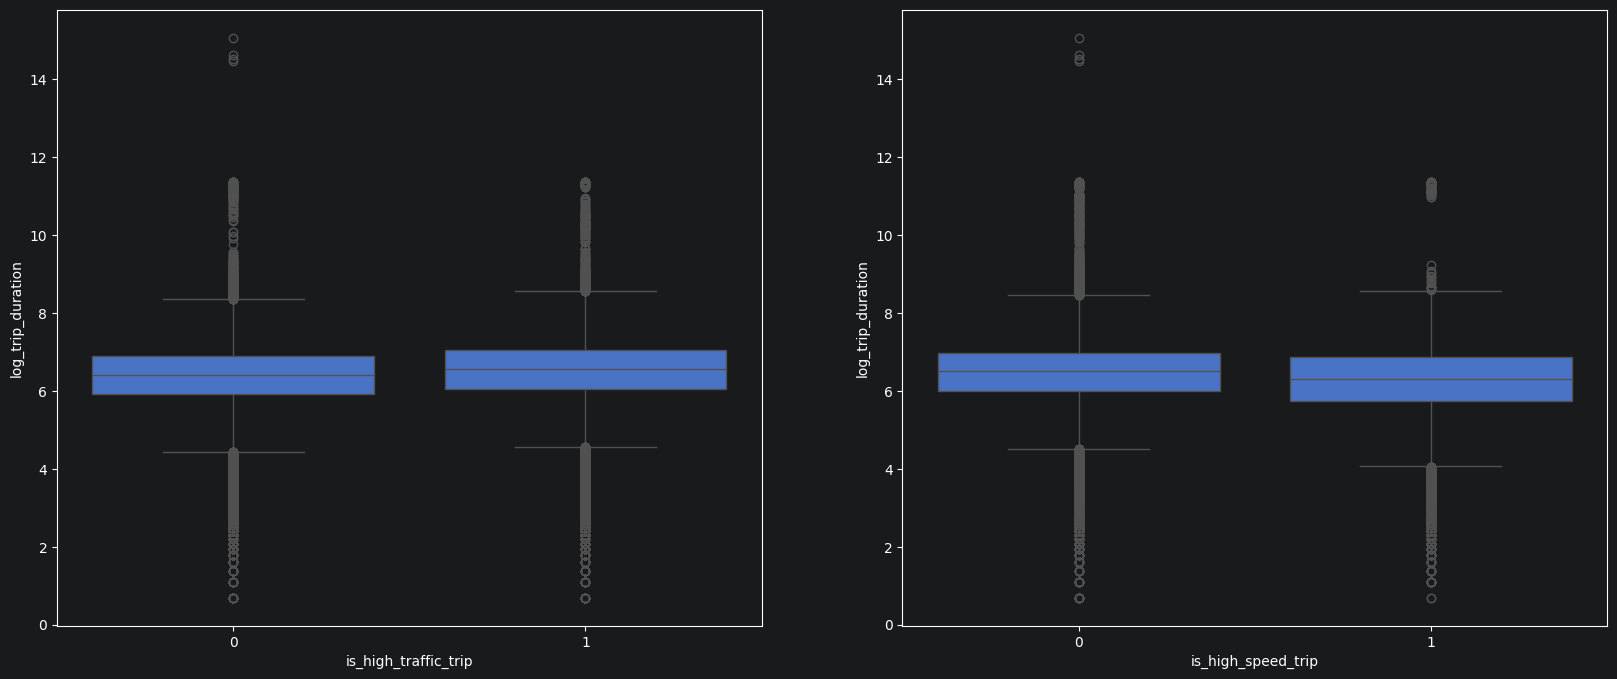

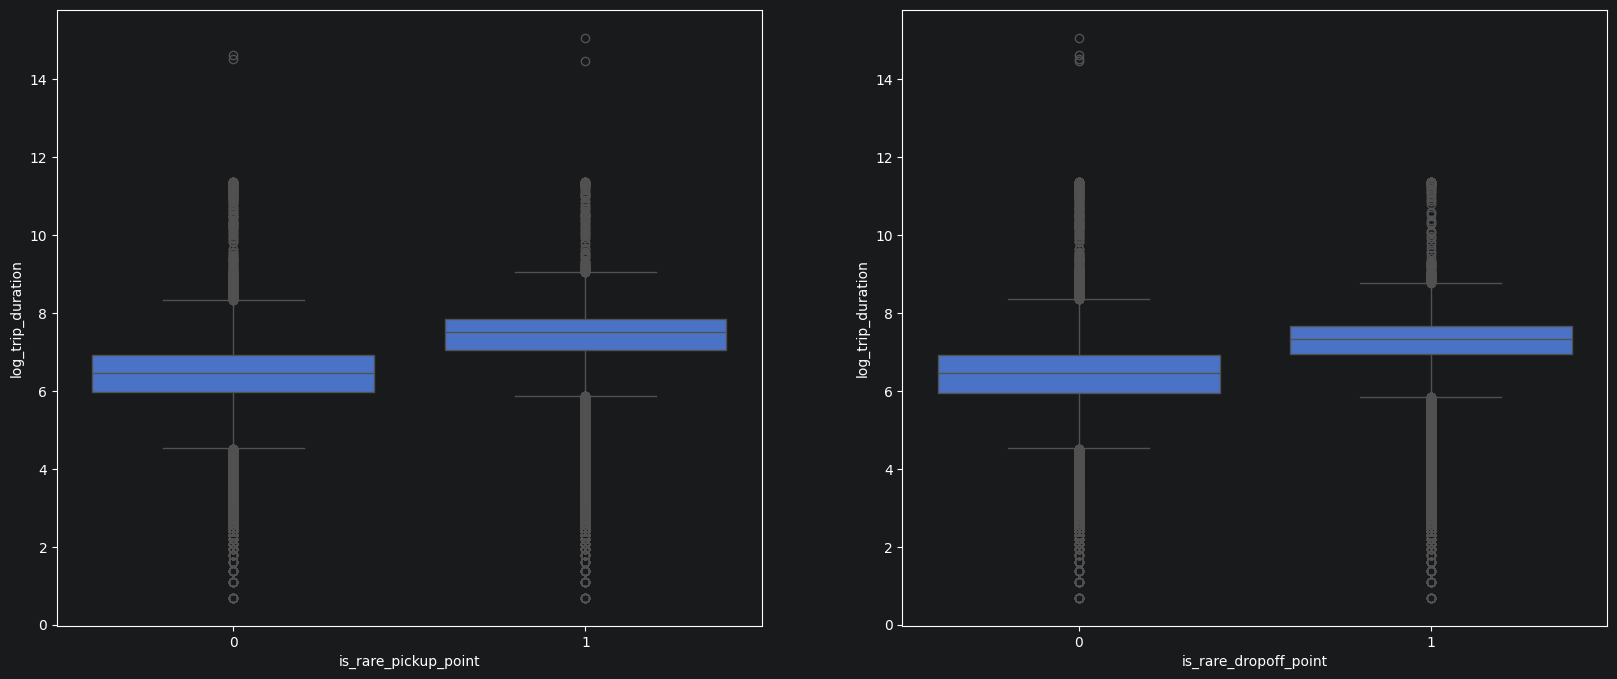

In [22]:
# final features
X = add_distance_features(X)
X = add_trip_type_features(X)
X = undo_step3_process_features(X)
X_train = add_model_features(X_train, abnormal_dates)
X_test = add_model_features(X_test, abnormal_dates)

sns.relplot(data=X, x="log_distance_haversine", y=y)
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sns.boxplot(x=X["is_high_traffic_trip"], y=y, ax=ax[0])
sns.boxplot(x=X["is_high_speed_trip"], y=y, ax=ax[1])
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sns.boxplot(x=X["is_rare_pickup_point"], y=y, ax=ax[0])
sns.boxplot(x=X["is_rare_dropoff_point"], y=y, ax=ax[1])
plt.show()